In [45]:
import pandas as pd
import numpy as np 

from pathlib import Path

# feature matrix (expression matrix)
X_path = Path("../data/processed/luad_X.parquet")

# labels path
labels_path = Path("../data/processed/luad_labels.csv")

X = pd.read_parquet(X_path)
labels = pd.read_csv(labels_path)

X.shape, labels.shape

((574, 20530), (574, 3))

In [46]:
# verifying the feature vs label alignment
X.index[:5], labels.head()

(Index(['TCGA-69-7978-01', 'TCGA-62-8399-01', 'TCGA-78-7539-01',
        'TCGA-50-5931-11', 'TCGA-73-4658-01'],
       dtype='str'),
          sample_id sample_type  label
 0  TCGA-69-7978-01       tumor    1.0
 1  TCGA-62-8399-01       tumor    1.0
 2  TCGA-78-7539-01       tumor    1.0
 3  TCGA-50-5931-11      normal    0.0
 4  TCGA-73-4658-01       tumor    1.0)

In [47]:
(X.index == labels["sample_id"]).all()

np.True_

In [48]:
# Creating feature matric and target vector

y = labels["label"]

X_values = X

In [49]:
labels["sample_type"].value_counts()

sample_type
tumor     515
normal     59
Name: count, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_values,
    y,
    test_size=0.2, # 20% → test, 80% → train
    random_state=42, # shuffle seed
    stratify=y, # Keep tumor/normal ratio similar in train and test
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((459, 20530),
 (115, 20530),
 label
 1.0    412
 0.0     47
 Name: count, dtype: int64,
 label
 1.0    103
 0.0     12
 Name: count, dtype: int64)

In [52]:
# scaled_value = (original_value - mean_of_that_gene) / std_of_that_gene

# creates empty scaler object
scaler = StandardScaler()

# fit -> Look at X_train, compute mean and std per column (per gene)
# transform -> Apply (x - mean) / std to every value in X_train
X_train_scaled = scaler.fit_transform(X_train)

# no fit because uses same mean and std_dev from X_Train
X_test_scaled = scaler.transform(X_test)

''' 
correct :
  fit on X_train  -> learn statistics from training data only
  transform X_train and X_test with those statistics

wrong:
  fit on all data (train + test)
  test information leaks into scaling
  evaluation looks better than it should
''' 

' \ncorrect :\n  fit on X_train  -> learn statistics from training data only\n  transform X_train and X_test with those statistics\n\nwrong:\n  fit on all data (train + test)\n  test information leaks into scaling\n  evaluation looks better than it should\n'

In [53]:
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [54]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["normal", "tumor"]))

Accuracy: 1.0
Balanced accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0

Confusion matrix:
[[ 12   0]
 [  0 103]]

Classification report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        12
       tumor       1.00      1.00      1.00       103

    accuracy                           1.00       115
   macro avg       1.00      1.00      1.00       115
weighted avg       1.00      1.00      1.00       115



## Visualizations


In [69]:
import matplotlib.pyplot as plt

# Shared chart styling for every plot in this section
plt.rcParams.update({
    "figure.facecolor": "#F7F8FA",   # light gray area around the plot
    "axes.facecolor": "#FFFFFF",     # white plot background
    "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": "#374151",
    "text.color": "#111827",
    "xtick.color": "#6B7280",
    "ytick.color": "#1F2937",
    "font.size": 9,
})

# Same colors everywhere: normal = blue, tumor = coral
PALETTE = {
    "normal": "#5B8DB8",
    "tumor": "#D4726A",
}
LABEL_MAP = {0.0: "normal", 1.0: "tumor"}


### 1. Class balance

How many tumor vs normal samples exist in the full dataset?


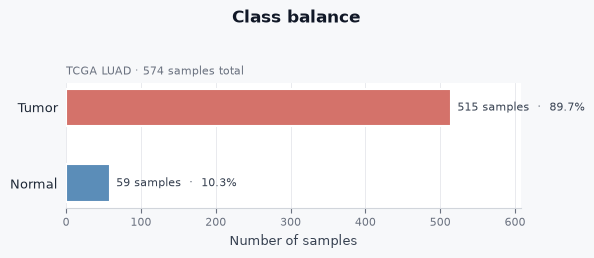

In [70]:
# Count tumor vs normal in the full dataset
counts = labels["sample_type"].value_counts().reindex(["normal", "tumor"])
total = counts.sum()
pct = counts / total * 100

fig, ax = plt.subplots(figsize=(6, 2.4))
y_pos = np.arange(len(counts))

# barh = horizontal bars; y_pos = row, counts.values = bar length
bars = ax.barh(
    y_pos,
    counts.values,
    height=0.5,
    color=[PALETTE[c] for c in counts.index],
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

ax.set_yticks(y_pos)
ax.set_yticklabels([c.capitalize() for c in counts.index], fontsize=9)
ax.set_xlabel("Number of samples", fontsize=9)
ax.set_xlim(0, counts.max() * 1.18)
ax.xaxis.grid(True, linestyle="-", linewidth=0.6, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)

for bar, cls in zip(bars, counts.index):
    ax.text(
        bar.get_width() + 8,
        bar.get_y() + bar.get_height() / 2,
        f"{int(counts[cls])} samples  ·  {pct[cls]:.1f}%",
        va="center",
        ha="left",
        fontsize=8,
        color="#374151",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Class balance", fontsize=12, fontweight="bold", y=1.05)
ax.set_title(f"TCGA LUAD · {total} samples total", fontsize=8, color="#6B7280", loc="left", pad=6)
plt.tight_layout()
plt.show()


### 2. Train / test split

After `train_test_split(..., stratify=y)`, both sets keep the same class ratio (~90% tumor).


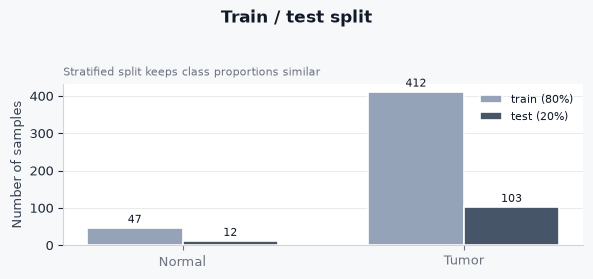

In [71]:
# Count labels in train and test separately
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# Build a small table: rows = class, columns = train/test
split_df = pd.DataFrame({"train": train_counts, "test": test_counts})
split_df.index = split_df.index.map(LABEL_MAP)

fig, ax = plt.subplots(figsize=(6, 2.6))
x = np.arange(len(split_df))
width = 0.34

# side-by-side bars for each class
train_bars = ax.bar(
    x - width / 2,
    split_df["train"],
    width,
    label="train (80%)",
    color="#94A3B8",
    edgecolor="white",
    linewidth=1.2,
)
test_bars = ax.bar(
    x + width / 2,
    split_df["test"],
    width,
    label="test (20%)",
    color="#475569",
    edgecolor="white",
    linewidth=1.2,
)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in split_df.index], fontsize=9)
ax.set_ylabel("Number of samples", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# write counts on top of each bar
for bars in (train_bars, test_bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 6, f"{int(h)}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Train / test split", fontsize=12, fontweight="bold", y=1.05)
ax.set_title("Stratified split keeps class proportions similar", fontsize=8, color="#6B7280", loc="left", pad=6)
plt.tight_layout()
plt.show()


### 3. StandardScaler effect

Each gene column is centered to mean 0 and scaled to std 1 using **training data only**.


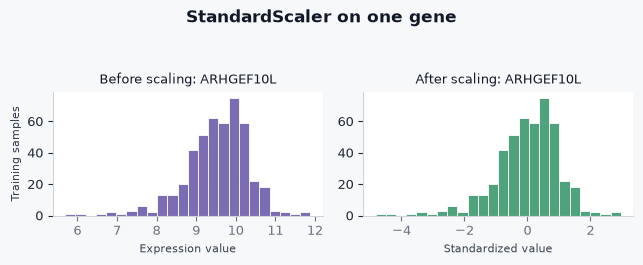

In [72]:
# Pick one example gene from the training columns
example_gene = X_train.columns[0]
gene_idx = X_train.columns.get_loc(example_gene)

raw_values = X_train[example_gene].values
scaled_values = X_train_scaled[:, gene_idx]

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.4))

# left panel: original expression values
axes[0].hist(raw_values, bins=24, color="#7C6CB4", edgecolor="white", linewidth=0.6)
axes[0].set_title(f"Before scaling: {example_gene}", fontsize=9)
axes[0].set_xlabel("Expression value", fontsize=8)
axes[0].set_ylabel("Training samples", fontsize=8)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# right panel: standardized values (mean ~ 0, std ~ 1)
axes[1].hist(scaled_values, bins=24, color="#4FA37C", edgecolor="white", linewidth=0.6)
axes[1].set_title(f"After scaling: {example_gene}", fontsize=9)
axes[1].set_xlabel("Standardized value", fontsize=8)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("StandardScaler on one gene", fontsize=12, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()


### 4. Sample separation (PCA)

Project 20,530 genes down to 2 dimensions so we can **see** whether tumor and normal samples separate.


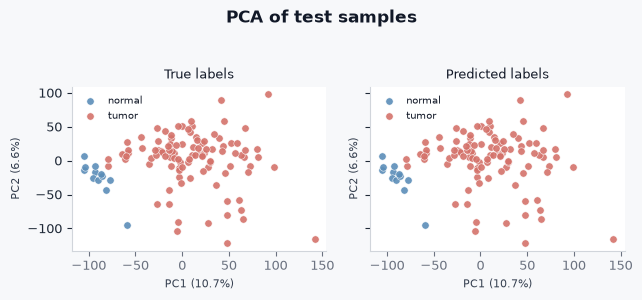

In [73]:
# PCA learns 2 directions of maximum variance in the scaled test data
pca = PCA(n_components=2, random_state=42)
test_2d = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8), sharex=True, sharey=True)

panels = [
    (axes[0], y_test, "True labels"),
    (axes[1], y_pred, "Predicted labels"),
]

for ax, labels_array, title in panels:
    normal_mask = labels_array == 0
    tumor_mask = labels_array == 1

    # scatter each class with its color
    ax.scatter(
        test_2d[normal_mask, 0], test_2d[normal_mask, 1],
        s=28, alpha=0.9, c=PALETTE["normal"], label="normal", edgecolors="white", linewidths=0.4,
    )
    ax.scatter(
        test_2d[tumor_mask, 0], test_2d[tumor_mask, 1],
        s=28, alpha=0.9, c=PALETTE["tumor"], label="tumor", edgecolors="white", linewidths=0.4,
    )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=8)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=8)
    ax.legend(frameon=False, fontsize=7, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("PCA of test samples", fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


### 5. Test-set evaluation

Confusion matrix, ROC curve, and predicted tumor probabilities on held-out test samples.


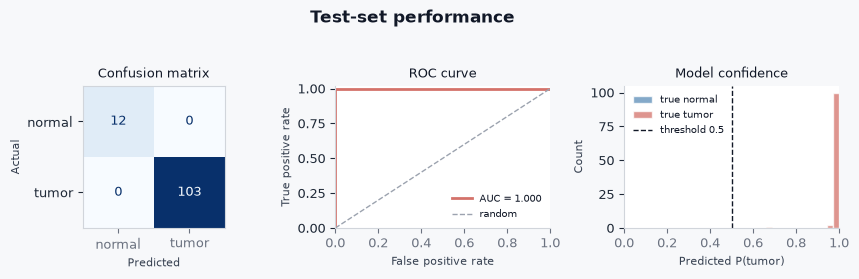

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))

# --- panel 1: confusion matrix heatmap ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "tumor"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, text_kw={"fontsize": 9})
axes[0].set_title("Confusion matrix", fontsize=9)
axes[0].set_xlabel("Predicted", fontsize=8)
axes[0].set_ylabel("Actual", fontsize=8)

# --- panel 2: ROC curve (uses probabilities, not hard 0/1 labels) ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=PALETTE["tumor"], lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="#9CA3AF", lw=1, label="random")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("False positive rate", fontsize=8)
axes[1].set_ylabel("True positive rate", fontsize=8)
axes[1].set_title("ROC curve", fontsize=9)
axes[1].legend(frameon=False, fontsize=7, loc="lower right")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# --- panel 3: predicted P(tumor) by true class ---
axes[2].hist(y_prob[y_test == 0], bins=12, alpha=0.75, label="true normal", color=PALETTE["normal"], edgecolor="white")
axes[2].hist(y_prob[y_test == 1], bins=12, alpha=0.75, label="true tumor", color=PALETTE["tumor"], edgecolor="white")
axes[2].axvline(0.5, color="#111827", linestyle="--", linewidth=1, label="threshold 0.5")
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Predicted P(tumor)", fontsize=8)
axes[2].set_ylabel("Count", fontsize=8)
axes[2].set_title("Model confidence", fontsize=9)
axes[2].legend(frameon=False, fontsize=7)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

fig.suptitle("Test-set performance", fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


### 6. Top gene weights

Largest logistic regression coefficients after scaling — genes that push predictions toward normal (blue) or tumor (coral).


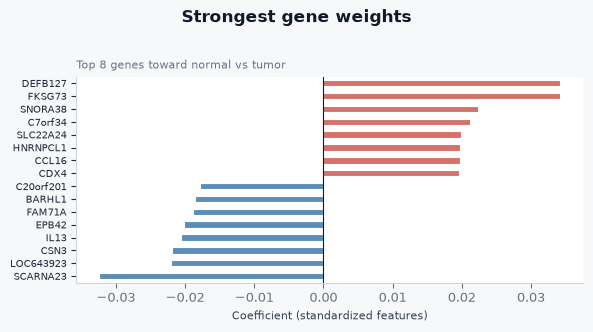

In [76]:
# model.coef_[0] = one weight per gene
coef = pd.Series(model.coef_[0], index=X_train.columns)
top_n = 8

top_tumor = coef.nlargest(top_n).iloc[::-1]
top_normal = coef.nsmallest(top_n)
combined = pd.concat([top_normal, top_tumor])

fig, ax = plt.subplots(figsize=(6, 3.2))
colors = [PALETTE["normal"] if v < 0 else PALETTE["tumor"] for v in combined.values]

combined.plot.barh(ax=ax, color=colors, edgecolor="white", linewidth=0.8)
ax.axvline(0, color="#111827", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized features)", fontsize=8)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle("Strongest gene weights", fontsize=12, fontweight="bold", y=1.02)
ax.set_title(f"Top {top_n} genes toward normal vs tumor", fontsize=8, color="#6B7280", loc="left", pad=6)
plt.tight_layout()
plt.show()


### 7. Model vs majority baseline

Compare our classifier to a naive rule: always predict tumor.


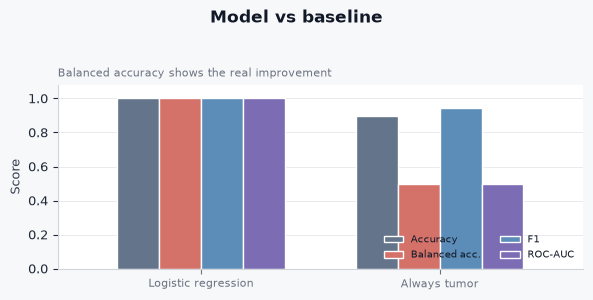

In [77]:
majority_pred = np.ones_like(y_test)

score_df = pd.DataFrame({
    "Logistic regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced acc.": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    },
    "Always tumor": {
        "Accuracy": accuracy_score(y_test, majority_pred),
        "Balanced acc.": balanced_accuracy_score(y_test, majority_pred),
        "F1": f1_score(y_test, majority_pred),
        "ROC-AUC": roc_auc_score(y_test, np.full_like(y_prob, y_train.mean())),
    },
}).T

fig, ax = plt.subplots(figsize=(6, 2.8))
score_df.plot.bar(ax=ax, rot=0, width=0.7, color=["#64748B", "#D4726A", "#5B8DB8", "#7C6CB4"], edgecolor="white")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=9)
ax.legend(frameon=False, fontsize=7, loc="lower right", ncol=2)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Model vs baseline", fontsize=12, fontweight="bold", y=1.05)
ax.set_title("Balanced accuracy shows the real improvement", fontsize=8, color="#6B7280", loc="left", pad=6)
plt.tight_layout()
plt.show()


## Sanity checks

In [78]:
(X.index == labels["sample_id"]).all()

np.True_

In [79]:
labels.head()

,sample_id,sample_type,label
0,TCGA-69-7978-01,tumor,1.0
1,TCGA-62-8399-01,tumor,1.0
2,TCGA-78-7539-01,tumor,1.0
3,TCGA-50-5931-11,normal,0.0
4,TCGA-73-4658-01,tumor,1.0


In [80]:
X.head()

gene,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
TCGA-69-7978-01,9.9898,4.2598,0.4181,10.3657,11.1718,10.5897,12.2708,4.7670,0.0000,8.2023,...,1.8836,0.7420,6.2348,0.0000,9.4520,12.7565,8.2668,11.2400,6.1209,9.8977
TCGA-62-8399-01,10.4257,11.6239,0.0000,11.5489,11.0200,9.2843,12.1540,5.7125,0.4628,5.5819,...,0.4628,1.5316,4.4464,1.3294,9.5226,12.2100,8.5437,10.3491,8.6398,9.7315
TCGA-78-7539-01,9.6264,9.1362,1.1231,11.6692,10.4679,10.4649,12.6559,4.3943,0.3725,3.5365,...,2.9588,0.0000,6.0400,3.9201,9.2765,10.6498,6.1814,11.1659,6.0970,10.3540
TCGA-50-5931-11,8.6835,9.4824,0.8221,11.7341,11.6787,11.5412,11.9285,5.9466,0.8221,3.3528,...,0.0000,2.4876,6.3782,0.0000,8.6781,14.6956,9.7151,10.5910,9.5115,10.4914
TCGA-73-4658-01,9.2078,5.0288,0.0000,11.6209,11.3414,10.9376,12.0539,6.0942,0.0000,7.4156,...,0.0000,0.6557,6.3898,1.1048,9.2697,13.0036,8.9786,10.6777,8.4187,10.3142


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, confusion_matrix

y_shuffled = y.sample(frac=1.0, random_state=123).reset_index(drop=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_values,
    y_shuffled,
    test_size=0.2,
    random_state=42,
    stratify=y_shuffled,
)

scaler_s = StandardScaler()

X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

model_s = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

model_s.fit(X_train_s_scaled, y_train_s)

y_pred_s = model_s.predict(X_test_s_scaled)
y_prob_s = model_s.predict_proba(X_test_s_scaled)[:, 1]

print("Shuffled-label accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Shuffled-label balanced accuracy:", balanced_accuracy_score(y_test_s, y_pred_s))
print("Shuffled-label F1:", f1_score(y_test_s, y_pred_s))
print("Shuffled-label ROC-AUC:", roc_auc_score(y_test_s, y_prob_s))
print("\nConfusion matrix:")
print(confusion_matrix(y_test_s, y_pred_s))

Shuffled-label accuracy: 0.8869565217391304
Shuffled-label balanced accuracy: 0.49514563106796117
Shuffled-label F1: 0.9400921658986175
Shuffled-label ROC-AUC: 0.6270226537216829

Confusion matrix:
[[  0  12]
 [  1 102]]


In [82]:
majority_pred = np.ones_like(y_test)

print("Majority accuracy:", accuracy_score(y_test, majority_pred))
print("Majority balanced accuracy:", balanced_accuracy_score(y_test, majority_pred))
print("Majority F1:", f1_score(y_test, majority_pred))
print(confusion_matrix(y_test, majority_pred))

Majority accuracy: 0.8956521739130435
Majority balanced accuracy: 0.5
Majority F1: 0.944954128440367
[[  0  12]
 [  0 103]]
